# Titanic EDA Project

This project analyzes Titanic passenger data to identify survival patterns and important insights using Python and Pandas.


In [11]:
import pandas as pd

df = pd.read_csv("../dataset /titanic.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [10]:
import os

os.listdir("..")

['.DS_Store', 'anaconda_projects', 'notebook ', 'dataset ']

# Basic Information 


## Dataset Size

Checking the total number of rows and columns in the dataset.

In [32]:
df.shape

(891, 12)

In [12]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [13]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [14]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [33]:
df['Sex'].unique()

array(['male', 'female'], dtype=object)

In [34]:
df['Pclass'].unique()

array([3, 1, 2])

# Data Cleaning 

In [18]:
df['Age'] = df['Age'].fillna(df['Age'].median())


In [19]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [20]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

# Exploratory Data Analysis (EDA) 

## Survival Rate by Gender

In [21]:
df.groupby('Sex')['Survived'].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

## Survival Rate by Passenger Class

In [22]:
df.groupby('Pclass')['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

## Average Passenger Age

In [27]:
df['Age'].mean()

np.float64(29.36158249158249)

## Average Age per Class

In [28]:
df.groupby('Pclass')['Age'].mean()

Pclass
1    36.812130
2    29.765380
3    25.932627
Name: Age, dtype: float64

# Insights

1. Female passengers had a higher survival rate than male passengers.

2. First class passengers survived more compared to second and third class passengers.

3. Average passenger age was around 29 years.

4. Third class had the highest number of passengers.

5. Missing values in Age and Embarked columns were cleaned using median and mode.

# Data Visualization

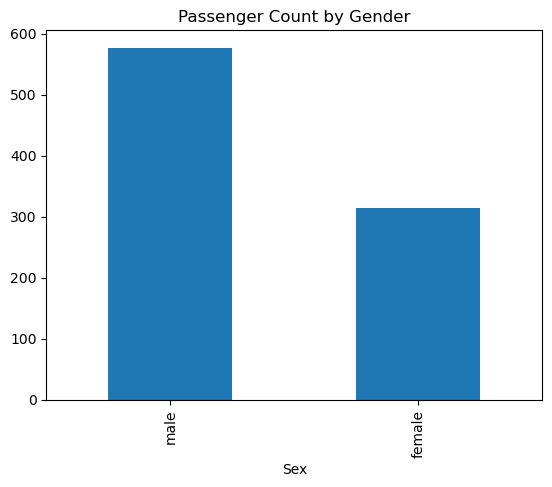

In [30]:
import matplotlib.pyplot as plt

df['Sex'].value_counts().plot(kind='bar')

plt.title("Passenger Count by Gender")

plt.show()

In [35]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

In [36]:
df = df.drop(columns=['Cabin'])

In [38]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [39]:
df['FamilySize']=df['SibSp'] + df['Parch'] + 1

In [40]:
df['IsAlone'] = df['FamilySize'].apply(lambda x: 1 if x == 1 else 0)

In [41]:
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


In [42]:
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,IsAlone,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2,0,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2,0,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1,1,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2,0,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1,1,Mr


In [45]:
df['Title'].value_counts()

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Mlle          2
Major         2
Col           2
Countess      1
Capt          1
Ms            1
Sir           1
Lady          1
Mme           1
Don           1
Jonkheer      1
Name: count, dtype: int64

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

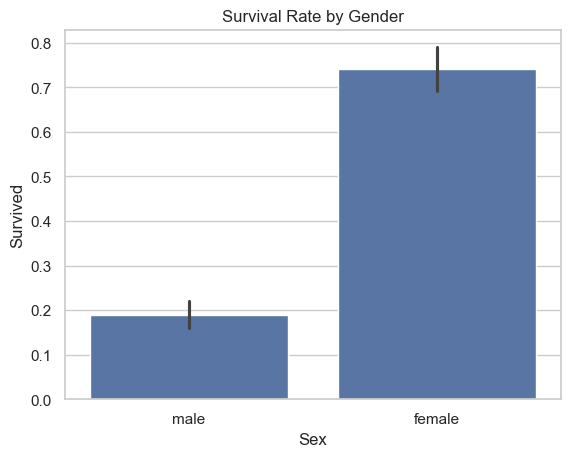

In [49]:
sns.barplot(x='Sex', y='Survived', data=df)
plt.title("Survival Rate by Gender")
plt.show()

Female passengers had significantly higher survival rates compared to male passengers.

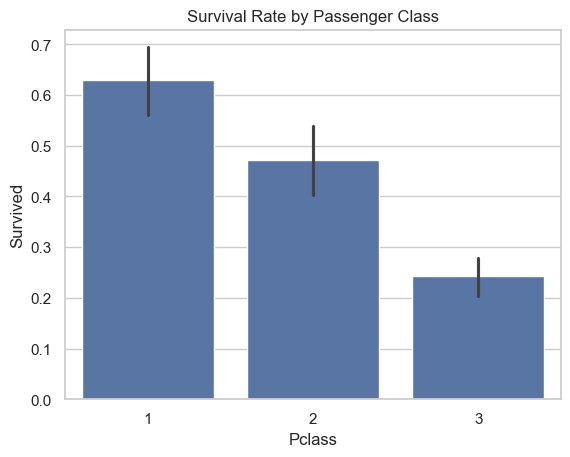

In [50]:
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title("Survival Rate by Passenger Class")
plt.show()

Passengers in first class had the highest survival rate, while third class had the lowest.

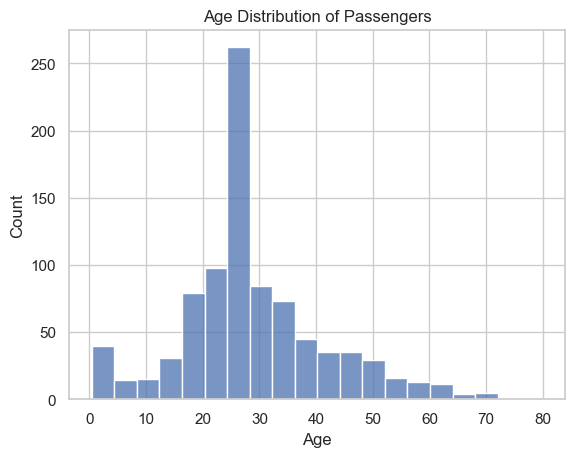

In [51]:
sns.histplot(df['Age'], bins=20)
plt.title("Age Distribution of Passengers")
plt.show()

Most passengers were between the ages of 20 and 40.

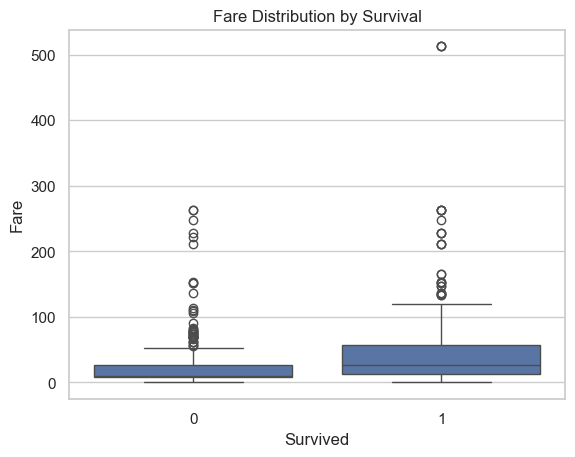

In [53]:
sns.boxplot(x='Survived', y='Fare', data=df)
plt.title("Fare Distribution by Survival")
plt.show()

Passengers who paid higher fares had a higher chance of survival.

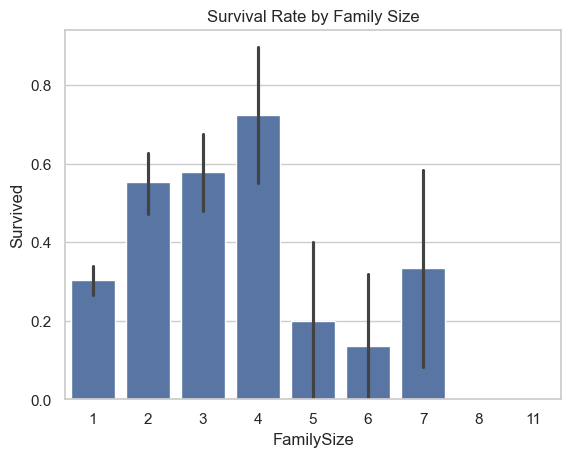

In [55]:
sns.barplot(x='FamilySize', y='Survived', data=df)
plt.title("Survival Rate by Family Size")
plt.show()

Passengers traveling with small families had better survival rates compared to those traveling alone or in large groups.

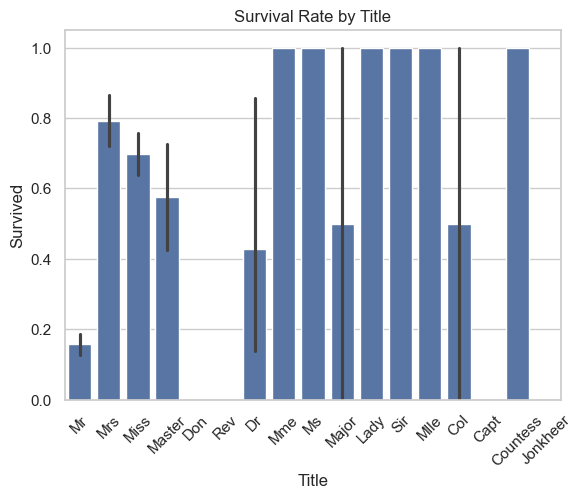

In [56]:
sns.barplot(x='Title', y='Survived', data=df)
plt.title("Survival Rate by Title")
plt.xticks(rotation=45)
plt.show()

Female-related titles like 'Mrs' and 'Miss' had higher survival rates compared to 'Mr'.